# QTCAD M03 Gate Sweep — Full Result Analysis

이 노트북은 아래 QTCAD 예제 폴더의 결과를 가능한 한 많이 읽고 분석합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference`

분석 대상:
- `output/detuning_and_coupling.txt`
- `output/tunnel_coupling_energies.txt`
- `output/tunnel_coupling_low_barrier.txt`
- `output/tunnel_coupling_final_potential.hdf5`
- `output/tunnel_coupling_wavefunctions_high_barrier.vtu`
- `output/tunnel_coupling_wavefunctions_low_barrier.vtu`
- `meshes/dqdfdsoi.msh`
- `meshes/refined_dqdfdsoi.msh`
- `meshes/dqdfdsoi.geo`

주요 산출물:
1. 최적 detuning / 최소 splitting
2. \(E_0\sim E_9\) 전체 에너지 스펙트럼
3. \(E_0,E_1\) 확대
4. tunnel splitting 선형 / semilog
5. exponential fit 및 \(R^2\)
6. splitting의 주파수 환산
7. mesh refinement 통계
8. HDF5 electrostatic potential 통계
9. potential linecut
10. potential 2D 근사 slice
11. ParaView용 potential VTU export
12. high/low barrier wavefunction peak 위치
13. \(|\psi_0|^2\), \(|\psi_1|^2\) slice
14. channel 방향 wavefunction line profile
15. CSV/PNG 분석 결과 자동 저장

> 원본 QTCAD 파일은 수정하지 않습니다. 새 산출물은 `Reference\analysis_exports`에 저장합니다.


---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Device 16: Tunnel coupling in a DQD in FD-SOI, Part 1: Plunger gate tuning
  https://docs.nanoacademic.com/qtcad/tutorials/device/tunnel_coupling_1/
- **QTCAD 공식 튜토리얼** — Device 17: Tunnel coupling in a DQD in FD-SOI, Part 2: Barrier gate tuning
  https://docs.nanoacademic.com/qtcad/tutorials/device/tunnel_coupling_2/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `tunnel_coupling_1.py`, `tunnel_coupling_2.py` (M03/Reference)
---


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path
import gc
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference"
)

OUTPUT_DIR = BASE_DIR / "output"
MESH_DIR = BASE_DIR / "meshes"
EXPORT_DIR = BASE_DIR / "analysis_exports"

EXPORT_DIR.mkdir(exist_ok=True)

# 주요 파일
FILE_DETUNING = OUTPUT_DIR / "detuning_and_coupling.txt"
FILE_ENERGIES = OUTPUT_DIR / "tunnel_coupling_energies.txt"
FILE_LOW_BARRIER = OUTPUT_DIR / "tunnel_coupling_low_barrier.txt"
FILE_PHI = OUTPUT_DIR / "tunnel_coupling_final_potential.hdf5"

FILE_WF_HIGH = OUTPUT_DIR / "tunnel_coupling_wavefunctions_high_barrier.vtu"
FILE_WF_LOW = OUTPUT_DIR / "tunnel_coupling_wavefunctions_low_barrier.vtu"

FILE_MESH_ORIGINAL = MESH_DIR / "dqdfdsoi.msh"
FILE_MESH_REFINED = MESH_DIR / "refined_dqdfdsoi.msh"
FILE_GEO = MESH_DIR / "dqdfdsoi.geo"

# 분석 위치
Z_PHI_LINECUT_NM = -1.0
Z_PHI_SLICE_NM = -2.0
Z_WF_SLICE_NM = -2.0

SAVE_FIGURES = True
EXPORT_POTENTIAL_VTU = True

print("BASE_DIR  :", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MESH_DIR  :", MESH_DIR)
print("EXPORT_DIR:", EXPORT_DIR)

assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert OUTPUT_DIR.exists(), f"output 폴더가 없습니다:\n{OUTPUT_DIR}"
assert MESH_DIR.exists(), f"meshes 폴더가 없습니다:\n{MESH_DIR}"

print("\n[OK] 기본 경로 확인 완료")

BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference
OUTPUT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\output
MESH_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\meshes
EXPORT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\analysis_exports

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "detuning_and_coupling.txt": FILE_DETUNING,
    "tunnel_coupling_energies.txt": FILE_ENERGIES,
    "tunnel_coupling_low_barrier.txt": FILE_LOW_BARRIER,
    "tunnel_coupling_final_potential.hdf5": FILE_PHI,
    "wavefunctions_high_barrier.vtu": FILE_WF_HIGH,
    "wavefunctions_low_barrier.vtu": FILE_WF_LOW,
    "dqdfdsoi.msh": FILE_MESH_ORIGINAL,
    "refined_dqdfdsoi.msh": FILE_MESH_REFINED,
    "dqdfdsoi.geo": FILE_GEO,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_MB": path.stat().st_size / (1024**2) if path.exists() else np.nan,
        "path": str(path),
    })

inventory_df = pd.DataFrame(rows)
display(inventory_df)

missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
if missing:
    print("\n[주의] 없는 파일:", missing)
else:
    print("\n[OK] 분석 대상 파일이 모두 존재합니다.")

,file,exists,size_MB,path
0,detuning_and_coupling.txt,True,0.000051,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
1,tunnel_coupling_energies.txt,True,0.001842,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
2,tunnel_coupling_low_barrier.txt,True,0.000025,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
3,tunnel_coupling_final_potential.hdf5,True,1.122874,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
4,wavefunctions_high_barrier.vtu,True,128.215021,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
5,wavefunctions_low_barrier.vtu,True,128.224200,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
6,dqdfdsoi.msh,True,0.246776,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
7,refined_dqdfdsoi.msh,True,43.106817,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
8,dqdfdsoi.geo,True,0.004639,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...



[OK] 분석 대상 파일이 모두 존재합니다.


## 1. Geometry 파일에서 구조 치수 읽기

`dqdfdsoi.geo`의 정의값을 읽고 주요 소자 치수를 다시 계산합니다.


In [3]:
# [동작] .geo에서 단순 수치 변수 추출
geo_text = FILE_GEO.read_text(encoding="utf-8", errors="ignore")

pattern = re.compile(
    r"^\s*([A-Za-z_]\w*)\s*=\s*([-+]?\d+(?:\.\d+)?)\s*;",
    flags=re.MULTILINE,
)

geo_vars = {name: float(value) for name, value in pattern.findall(geo_text)}

wanted = [
    "domain_width",
    "channel_width",
    "gap_len_1", "gap_len_2", "gap_len_3",
    "gap_len_4", "gap_len_5", "gap_len_6",
    "plunger_gate_len",
    "barrier_gate_len",
    "source_drain_len",
    "gate_oxide_thick",
    "film_thick",
    "box_thick",
]

geometry_rows = [{"parameter": k, "value_nm": geo_vars.get(k, np.nan)} for k in wanted]
geometry_df = pd.DataFrame(geometry_rows)

# 계산 가능한 주요 길이
if all(k in geo_vars for k in [
    "gap_len_1", "gap_len_2", "gap_len_3", "gap_len_4", "gap_len_5", "gap_len_6",
    "barrier_gate_len", "plunger_gate_len", "source_drain_len"
]):
    channel_len_nm = sum(geo_vars[f"gap_len_{i}"] for i in range(1, 7)) \
                     + 3 * geo_vars["barrier_gate_len"] \
                     + 2 * geo_vars["plunger_gate_len"]
    domain_len_nm = 2 * geo_vars["source_drain_len"] + channel_len_nm
else:
    channel_len_nm = np.nan
    domain_len_nm = np.nan

display(geometry_df)
print(f"Calculated active channel length : {channel_len_nm:.3f} nm")
print(f"Calculated total domain length   : {domain_len_nm:.3f} nm")

,parameter,value_nm
0,domain_width,60.0
1,channel_width,40.0
2,gap_len_1,5.0
3,gap_len_2,5.0
4,gap_len_3,5.0
5,gap_len_4,5.0
6,gap_len_5,5.0
7,gap_len_6,5.0
8,plunger_gate_len,15.0
9,barrier_gate_len,10.0


Calculated active channel length : 90.000 nm
Calculated total domain length   : 130.000 nm


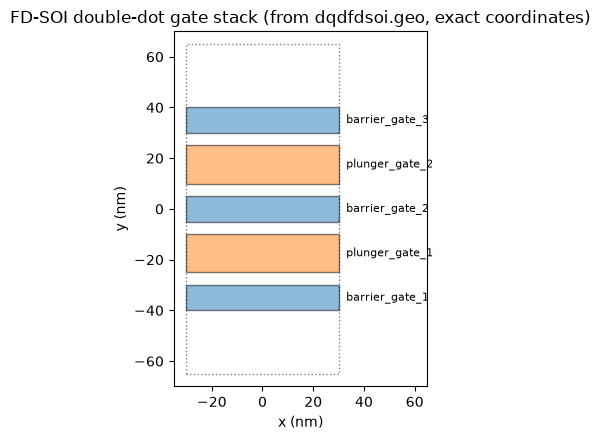

[재질] source/drain: Si n+ (1e20/cm3) | channel: Si (undoped, film_thick=10nm) | gate oxide: HfO2 (2nm) | buried oxide: SiO2 (10nm) | gates: metal (barrier/plunger)
barrier_gate_2(스윕 대상)가 두 플런저 사이 중앙에 위치 — 이 게이트 전압을 낮출수록 두 dot 사이 장벽이 낮아져 tunnel coupling이 커지는 구조입니다.


In [4]:
# [실험] 소자 스케매틱 시각화 (위에서 읽은 geo_vars 그대로 사용)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

temp = -channel_len_nm / 2 + geo_vars["gap_len_1"]
lens = [geo_vars["barrier_gate_len"], geo_vars["plunger_gate_len"], geo_vars["barrier_gate_len"],
       geo_vars["plunger_gate_len"], geo_vars["barrier_gate_len"]]
gap_keys = ["gap_len_2", "gap_len_3", "gap_len_4", "gap_len_5", "gap_len_6"]
names = ["barrier_gate_1", "plunger_gate_1", "barrier_gate_2", "plunger_gate_2", "barrier_gate_3"]
segs = []
for name, L, gk in zip(names, lens, gap_keys):
    segs.append((name, temp, temp + L)); temp = temp + geo_vars[gk] + L

fig, ax = plt.subplots(figsize=(10, 4.5))
dw = geo_vars["domain_width"]
ax.add_patch(mpatches.Rectangle((-dw/2, -domain_len_nm/2), dw, domain_len_nm, fill=False, ls=":", ec="0.5"))
for name, y0, y1 in segs:
    ax.add_patch(mpatches.Rectangle((-dw/2, y0), dw, y1 - y0,
                                    fc="tab:orange" if "plunger" in name else "tab:blue",
                                    alpha=0.5, ec="k"))
    ax.text(dw/2 + 3, (y0 + y1) / 2, name, va="center", fontsize=8)
ax.set_xlim(-dw/2-5, dw/2+35); ax.set_ylim(-domain_len_nm/2-5, domain_len_nm/2+5)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
ax.set_title("FD-SOI double-dot gate stack (from dqdfdsoi.geo, exact coordinates)")
fig.tight_layout()
plt.show()

print(
    "[재질] source/drain: Si n+ (1e20/cm3) | channel: Si (undoped, film_thick="
    f"{geo_vars.get('film_thick',10):.0f}nm) | gate oxide: HfO2 ({geo_vars.get('gate_oxide_thick',2):.0f}nm) | "
    f"buried oxide: SiO2 ({geo_vars.get('box_thick',10):.0f}nm) | gates: metal (barrier/plunger)\n"
    "barrier_gate_2(스윕 대상)가 두 플런저 사이 중앙에 위치 — 이 게이트 전압을 낮출수록"
    " 두 dot 사이 장벽이 낮아져 tunnel coupling이 커지는 구조입니다."
)


In [5]:
# [동작] MSH PhysicalNames 읽기
def parse_physical_names(msh_path):
    lines = msh_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    if "$PhysicalNames" not in lines:
        return pd.DataFrame(columns=["dimension", "tag", "name"])

    i = lines.index("$PhysicalNames")
    n = int(lines[i + 1].strip())
    out = []
    for line in lines[i + 2 : i + 2 + n]:
        m = re.match(r'\s*(\d+)\s+(\d+)\s+"(.+)"', line)
        if m:
            out.append({
                "dimension": int(m.group(1)),
                "tag": int(m.group(2)),
                "name": m.group(3),
            })
    return pd.DataFrame(out)

physical_names_df = parse_physical_names(FILE_MESH_ORIGINAL)
display(physical_names_df)

,dimension,tag,name
0,2,1,barrier_gate_1_bnd
1,2,2,plunger_gate_1_bnd
2,2,3,barrier_gate_2_bnd
3,2,4,plunger_gate_2_bnd
4,2,5,barrier_gate_3_bnd
5,2,8,source_bnd
6,2,9,drain_bnd
7,2,16,back_gate_bnd
8,3,6,gate_oxide_dot
9,3,7,gate_oxide


## 2. Scalar 결과: detuning / tunnel splitting

**물리 모델**: barrier_gate_2 전압을 낮춰 두 dot 사이 장벽을 낮추면, 바닥/첫들뜬
궤도 간격 $E_1-E_0$는 (M13/M16과 같은) 2-level anticrossing 모델의 비대칭 영역에서
$E_1-E_0 \approx 2t$(디튜닝이 거의 0인 영역)로 근사되며, $t$=tunnel coupling(유효
결합)입니다. Barrier가 낮아질수록 $t$가 지수적으로 커지므로, 아래 4절에서
$\ln(E_1-E_0)$ 대 barrier 전압이 선형(지수 함수의 로그)에 가까운지 확인합니다.

In [6]:
# [동작] detuning과 최소 splitting 읽기
detuning, min_splitting_eV = np.loadtxt(FILE_DETUNING)

detuning_uV = detuning * 1e6
min_splitting_ueV = min_splitting_eV * 1e6

P2_reference_V = 0.59
P2_optimum_V = P2_reference_V + detuning

print(f"Optimal detuning   : {detuning:.12e} V")
print(f"                   : {detuning_uV:.6f} µV")
print(f"Optimal P2 voltage : {P2_optimum_V:.9f} V")
print(f"Minimum E1-E0      : {min_splitting_eV:.12e} eV")
print(f"                   : {min_splitting_ueV:.6f} µeV")

Optimal detuning   : -1.041462855804e-04 V
                   : -104.146286 µV
Optimal P2 voltage : 0.589895854 V
Minimum E1-E0      : 1.301023277736e-06 eV
                   : 1.301023 µeV


In [7]:
# [동작] low-barrier splitting 읽기
low_barrier_splitting_eV = float(np.loadtxt(FILE_LOW_BARRIER))
low_barrier_splitting_ueV = low_barrier_splitting_eV * 1e6

print(f"Low-barrier splitting : {low_barrier_splitting_eV:.12e} eV")
print(f"                      : {low_barrier_splitting_ueV:.6f} µeV")

Low-barrier splitting : 2.651278645089e-04 eV
                      : 265.127865 µeV


## 3. 전체 eigenenergy spectrum \(E_0\sim E_9\)

In [8]:
# [동작] eigenenergy table 읽기
energy_data = np.loadtxt(FILE_ENERGIES)

if energy_data.ndim == 1:
    energy_data = energy_data[None, :]

V_B2 = energy_data[:, 0]
energies_eV = energy_data[:, 1:]

n_states = energies_eV.shape[1]
energy_labels = [f"E{i}" for i in range(n_states)]

energies_meV = energies_eV * 1e3

spectrum_df = pd.DataFrame(energies_meV, columns=[f"{x}_meV" for x in energy_labels])
spectrum_df.insert(0, "V_B2_V", V_B2)

E0_eV = energies_eV[:, 0]
E1_eV = energies_eV[:, 1]
splitting_eV = E1_eV - E0_eV
splitting_ueV = splitting_eV * 1e6

display(spectrum_df)

spectrum_csv = EXPORT_DIR / "eigenenergy_spectrum_meV.csv"
spectrum_df.to_csv(spectrum_csv, index=False)
print("Saved:", spectrum_csv)

,V_B2_V,E0_meV,E1_meV,E2_meV,E3_meV,E4_meV,E5_meV,E6_meV,E7_meV,E8_meV,E9_meV
0,0.57,43.336152,43.601280,48.332562,48.614140,51.486923,54.941143,55.121608,55.405391,56.473005,59.966790
1,0.56,44.645707,44.739395,49.637614,49.757513,55.276661,56.431912,56.555220,57.025565,60.270192,62.045543
2,0.55,45.681426,45.723009,50.665541,50.745126,57.460893,57.550652,58.070851,58.832322,63.073961,63.850258
3,0.54,46.577269,46.599355,51.555674,51.621611,58.350898,58.433495,60.072451,60.400725,65.078453,65.419793
4,0.53,47.385213,47.397426,52.359482,52.417395,59.154461,59.234197,61.625423,61.777741,66.626278,66.802724
5,0.52,48.130423,48.136064,53.101144,53.152702,59.895775,59.973309,62.923910,63.005487,67.913796,68.040254
6,0.51,48.826996,48.828297,53.794737,53.840778,60.588976,60.664400,64.059353,64.113263,69.040149,69.156081


Saved: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\analysis_exports\eigenenergy_spectrum_meV.csv


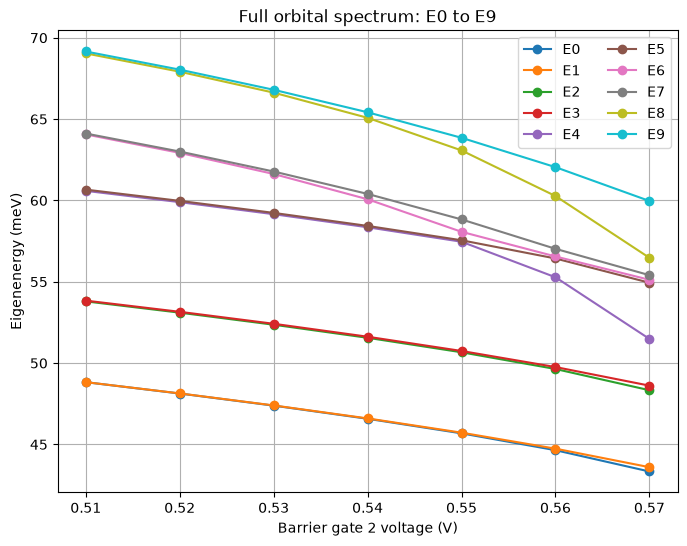

In [9]:
# [실험] E0 ~ E9 전체 spectrum
plt.figure(figsize=(8, 6))

for i in range(n_states):
    plt.plot(V_B2, energies_meV[:, i], marker="o", label=f"E{i}")

plt.xlabel("Barrier gate 2 voltage (V)")
plt.ylabel("Eigenenergy (meV)")
plt.title("Full orbital spectrum: E0 to E9")
plt.grid(True)
plt.legend(ncol=2)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "01_full_energy_spectrum_E0_E9.png", dpi=180, bbox_inches="tight")

plt.show()

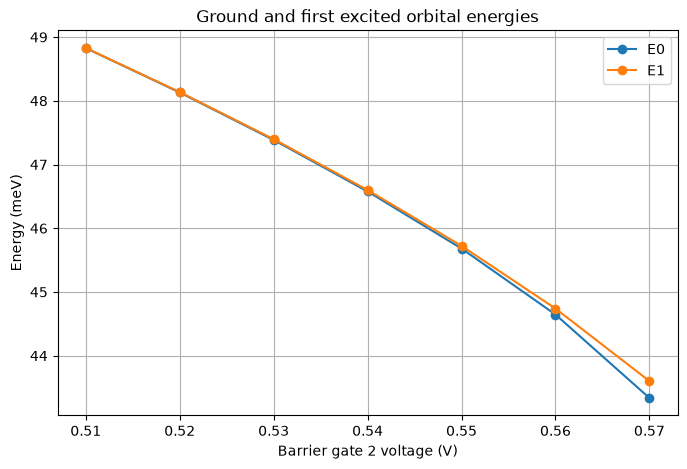

In [10]:
# [실험] E0 / E1 확대
plt.figure(figsize=(8, 5))
plt.plot(V_B2, E0_eV * 1e3, marker="o", label="E0")
plt.plot(V_B2, E1_eV * 1e3, marker="o", label="E1")
plt.xlabel("Barrier gate 2 voltage (V)")
plt.ylabel("Energy (meV)")
plt.title("Ground and first excited orbital energies")
plt.grid(True)
plt.legend()

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "02_E0_E1_zoom.png", dpi=180, bbox_inches="tight")

plt.show()

## 4. Tunnel splitting 및 exponential fit

**물리 모델 — WKB 지수 감쇠**: 사각형(또는 완만한) 장벽을 통한 터널링 진폭은 WKB
근사로 $t \propto \exp(-\int \kappa(x)\,dx)$ 형태이며, $\kappa(x)=\sqrt{2m^*(V(x)-E)}/\hbar$
입니다. Barrier 게이트 전압 $V_B$가 선형적으로 장벽 높이 $V_0$를 낮춘다고 가정하면
($V_0 \propto -\alpha V_B$, $\alpha$=barrier 게이트 lever arm), 적분이 대략
$\int\kappa\,dx \propto \sqrt{V_0} \propto \sqrt{-\alpha V_B}$로 바뀌어 **정확한 선형**은
아니지만, 좁은 전압 구간에서는 $\ln t$ vs $V_B$가 근사적으로 선형입니다 — 아래
지수 피팅은 이 근사를 전제로 한 것입니다.

In [11]:
# [동작] 주파수 환산 및 파생 지표
from scipy.constants import e as elementary_charge
from scipy.constants import h as planck_h

splitting_Hz = splitting_eV * elementary_charge / planck_h
splitting_GHz = splitting_Hz / 1e9

# 흔히 쓰는 2-level Hamiltonian convention에서 ΔE = 2 t_c 일 때의 값
tc_eV_if_half_splitting = splitting_eV / 2
tc_GHz_if_half_splitting = splitting_GHz / 2

metrics_df = pd.DataFrame({
    "V_B2_V": V_B2,
    "E0_meV": E0_eV * 1e3,
    "E1_meV": E1_eV * 1e3,
    "splitting_ueV": splitting_ueV,
    "splitting_GHz": splitting_GHz,
    "tc_ueV_if_DeltaE_eq_2tc": tc_eV_if_half_splitting * 1e6,
    "tc_GHz_if_DeltaE_eq_2tc": tc_GHz_if_half_splitting,
})

display(metrics_df)

metrics_csv = EXPORT_DIR / "tunnel_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)
print("Saved:", metrics_csv)

,V_B2_V,E0_meV,E1_meV,splitting_ueV,splitting_GHz,tc_ueV_if_DeltaE_eq_2tc,tc_GHz_if_DeltaE_eq_2tc
0,0.57,43.336152,43.601280,265.127865,64.107632,132.563932,32.053816
1,0.56,44.645707,44.739395,93.688000,22.653658,46.844000,11.326829
2,0.55,45.681426,45.723009,41.583169,10.054766,20.791585,5.027383
3,0.54,46.577269,46.599355,22.085597,5.340274,11.042799,2.670137
4,0.53,47.385213,47.397426,12.213235,2.953147,6.106618,1.476574
5,0.52,48.130423,48.136064,5.641022,1.363993,2.820511,0.681997
6,0.51,48.826996,48.828297,1.301124,0.314610,0.650562,0.157305


Saved: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\analysis_exports\tunnel_metrics.csv


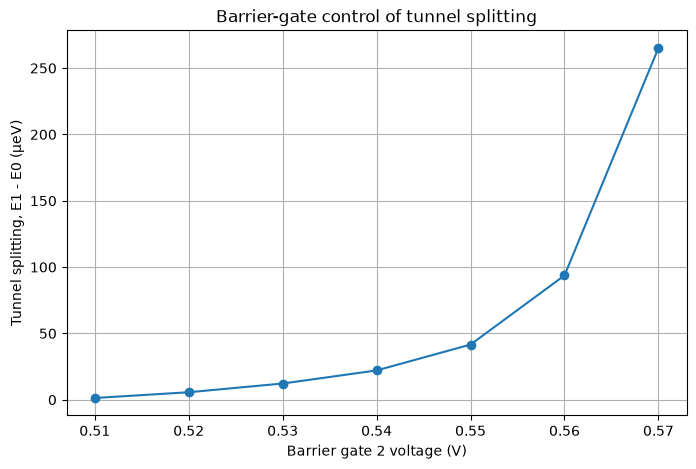

In [12]:
# [실험] Tunnel splitting - linear scale
plt.figure(figsize=(8, 5))
plt.plot(V_B2, splitting_ueV, marker="o")
plt.xlabel("Barrier gate 2 voltage (V)")
plt.ylabel("Tunnel splitting, E1 - E0 (µeV)")
plt.title("Barrier-gate control of tunnel splitting")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "03_tunnel_splitting_linear.png", dpi=180, bbox_inches="tight")

plt.show()

In [13]:
# [동작] QTCAD 예제와 동일한 log-domain exponential fit
# ln(ΔE) = alpha * V + ln(A)
fit_coeff = np.polyfit(V_B2, np.log(splitting_eV), 1)
alpha_per_V = fit_coeff[0]
A_eV = np.exp(fit_coeff[1])

fit_eV = A_eV * np.exp(alpha_per_V * V_B2)

# R^2 in log domain
y = np.log(splitting_eV)
y_hat = np.log(fit_eV)
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2_log = 1 - ss_res / ss_tot

print(f"Fit model : ΔE = A exp(alpha * V_B2)")
print(f"A         : {A_eV:.6e} eV")
print(f"alpha     : {alpha_per_V:.6f} 1/V")
print(f"R^2 (log) : {r2_log:.8f}")

Fit model : ΔE = A exp(alpha * V_B2)
A         : 1.725641e-24 eV
alpha     : 81.414060 1/V
R^2 (log) : 0.98247170


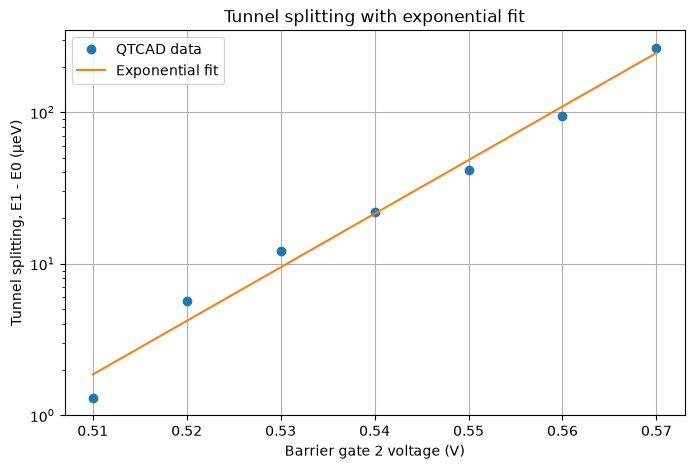

In [14]:
# [실험] Semilog + exponential fit
V_dense = np.linspace(np.min(V_B2), np.max(V_B2), 300)
fit_dense_ueV = A_eV * np.exp(alpha_per_V * V_dense) * 1e6

plt.figure(figsize=(8, 5))
plt.semilogy(V_B2, splitting_ueV, marker="o", linestyle="none", label="QTCAD data")
plt.semilogy(V_dense, fit_dense_ueV, label="Exponential fit")
plt.xlabel("Barrier gate 2 voltage (V)")
plt.ylabel("Tunnel splitting, E1 - E0 (µeV)")
plt.title("Tunnel splitting with exponential fit")
plt.grid(True)
plt.legend()

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "04_tunnel_splitting_semilog_fit.png", dpi=180, bbox_inches="tight")

plt.show()

In [15]:
# [동작] 구간별 민감도
# 중앙차분에 가까운 numpy.gradient 사용
d_split_dV_ueV_per_V = np.gradient(splitting_ueV, V_B2)
dln_split_dV_per_V = np.gradient(np.log(splitting_ueV), V_B2)

sensitivity_df = pd.DataFrame({
    "V_B2_V": V_B2,
    "splitting_ueV": splitting_ueV,
    "d_split_dV_ueV_per_V": d_split_dV_ueV_per_V,
    "dln_split_dV_per_V": dln_split_dV_per_V,
})
display(sensitivity_df)

print(
    "Total tuning ratio (max/min) = "
    f"{np.max(splitting_ueV) / np.min(splitting_ueV):.3f} x"
)

,V_B2_V,splitting_ueV,d_split_dV_ueV_per_V,dln_split_dV_per_V
0,0.57,265.127865,17143.986417,104.024210
1,0.56,93.688000,11177.234772,92.625836
2,0.55,41.583169,3580.120166,72.252222
3,0.54,22.085597,1468.496680,61.258763
4,0.53,12.213235,822.228753,68.243022
5,0.52,5.641022,545.605588,111.964598
6,0.51,1.301124,433.989825,146.683697


Total tuning ratio (max/min) = 203.768 x


## 5. HDF5 electrostatic potential \(\phi\)

먼저 HDF5 내부 구조를 확인한 뒤 `phi`를 읽습니다.


In [16]:
# [동작] HDF5 tree 재귀 출력
def print_hdf5_tree(group, prefix=""):
    for key, item in group.items():
        if isinstance(item, h5py.Dataset):
            print(
                f"{prefix}{key}  "
                f"shape={item.shape}, dtype={item.dtype}"
            )
        else:
            print(f"{prefix}{key}/")
            print_hdf5_tree(item, prefix + "  ")

with h5py.File(FILE_PHI, "r") as f:
    print_hdf5_tree(f)

phi  shape=(173626,), dtype=float64


In [17]:
# [동작] phi 읽기 및 통계
with h5py.File(FILE_PHI, "r") as f:
    phi = f["phi"][:]

phi_percentiles = np.percentile(phi, [0, 1, 5, 25, 50, 75, 95, 99, 100])

phi_stats_df = pd.DataFrame({
    "percentile": [0, 1, 5, 25, 50, 75, 95, 99, 100],
    "phi_V": phi_percentiles,
})

print("phi shape :", phi.shape)
print("phi dtype :", phi.dtype)
print("NaN count :", np.isnan(phi).sum())
print("Inf count :", np.isinf(phi).sum())
print("Mean      :", np.mean(phi), "V")
print("Std       :", np.std(phi), "V")
display(phi_stats_df)

phi shape : (173626,)
phi dtype : float64
NaN count : 0
Inf count : 0
Mean      : 0.3664111934294613 V
Std       : 0.1673938820731152 V


,percentile,phi_V
0,0,0.037005
1,1,0.037005
2,5,0.037005
3,25,0.232588
4,50,0.419517
5,75,0.500000
6,95,0.581741
7,99,0.630135
8,100,0.642937


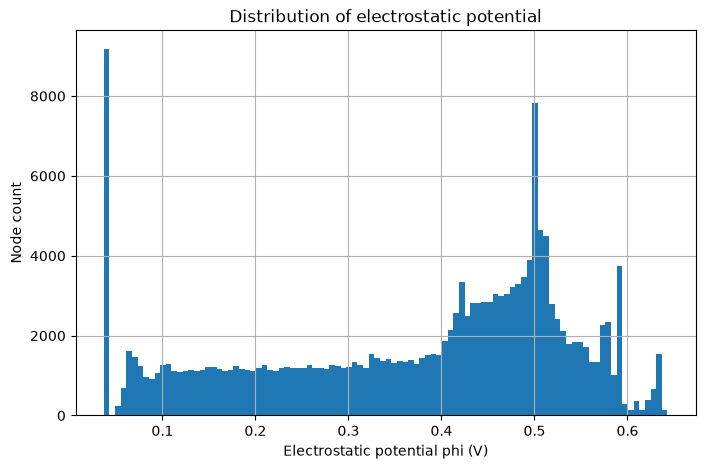

In [18]:
# [실험] phi distribution
plt.figure(figsize=(8, 5))
plt.hist(phi, bins=100)
plt.xlabel("Electrostatic potential phi (V)")
plt.ylabel("Node count")
plt.title("Distribution of electrostatic potential")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "05_phi_histogram.png", dpi=180, bbox_inches="tight")

plt.show()

## 6. Mesh + HDF5 결합

여기부터는 **QTCAD 환경**이 필요합니다.  
`refined_dqdfdsoi.msh`의 node 좌표와 HDF5의 `phi`를 연결합니다.


In [19]:
# [동작] QTCAD mesh 로드
try:
    from qtcad.device.mesh3d import Mesh
    from qtcad.device import io
    from qtcad.device import analysis as an

    HAVE_QTCAD = True
    print("[OK] QTCAD import 성공")
except Exception as exc:
    HAVE_QTCAD = False
    print("[주의] QTCAD import 실패:", repr(exc))
    print("Jupyter kernel이 qtcad conda 환경인지 확인하세요.")


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.2.6                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

[OK] QTCAD import 성공


In [20]:
# [동작] original / refined mesh 비교
if HAVE_QTCAD:
    mesh_original = Mesh(1e-9, FILE_MESH_ORIGINAL)
    mesh_refined = Mesh(1e-9, FILE_MESH_REFINED)

    n_original = mesh_original.glob_nodes.shape[0]
    n_refined = mesh_refined.glob_nodes.shape[0]

    xyz = mesh_refined.glob_nodes
    xyz_nm = xyz / 1e-9

    print(f"Original mesh nodes : {n_original:,}")
    print(f"Refined mesh nodes  : {n_refined:,}")
    print(f"Node refinement ratio: {n_refined / n_original:.3f} x")

    print("\nRefined mesh coordinate range [nm]")
    print(f"x : {xyz_nm[:,0].min():.3f} ~ {xyz_nm[:,0].max():.3f}")
    print(f"y : {xyz_nm[:,1].min():.3f} ~ {xyz_nm[:,1].max():.3f}")
    print(f"z : {xyz_nm[:,2].min():.3f} ~ {xyz_nm[:,2].max():.3f}")

    print("\nphi values :", len(phi))
    print("mesh nodes :", n_refined)
    assert len(phi) == n_refined, "phi 길이와 refined mesh node 수가 다릅니다."
    print("[OK] phi[i] ↔ refined mesh node[i] 매칭 확인")

Loading mesh from file:
 C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\meshes\dqdfdsoi.msh


Done.
3D MESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      5084                
Triangular elements           404                 
Tetrahedral elements          4680                
Total number of nodes         1057                
Boundary physical names       barrier_gate_1_bnd, plunger_gate_1_bnd, barrier_gate_2_bnd, plunger_gate_2_bnd, barrier_gate_3_bnd, source_bnd, drain_bnd, back_gate_bnd, 
Region physical names         gate_oxide_dot, gate_oxide, source, drain, channel, oxide, channel_dot, oxide_dot, buried_oxide, buried_oxide_dot, 
Loading mesh from file:
 C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\meshes\refined_dqdfdsoi.msh


Done.
3D MESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      1022018             
Triangular elements           31435               
Tetrahedral elements          990583              
Total number of nodes         173626              
Boundary physical names       barrier_gate_1_bnd, plunger_gate_1_bnd, barrier_gate_2_bnd, plunger_gate_2_bnd, barrier_gate_3_bnd, source_bnd, drain_bnd, back_gate_bnd, 
Region physical names         gate_oxide_dot, gate_oxide, source, drain, channel, oxide, channel_dot, oxide_dot, buried_oxide, buried_oxide_dot, 
Original mesh nodes : 1,057
Refined mesh nodes  : 173,626
Node refinement ratio: 164.263 x

Refined mesh coordinate range [nm]
x : -30.000 ~ 30.000
y : -65.000 ~ 65.000
z : -20.000 ~ 2.000

phi values : 173626
mesh nodes : 173626
[OK] phi[i] ↔ refined mesh node[i] 매칭 확인


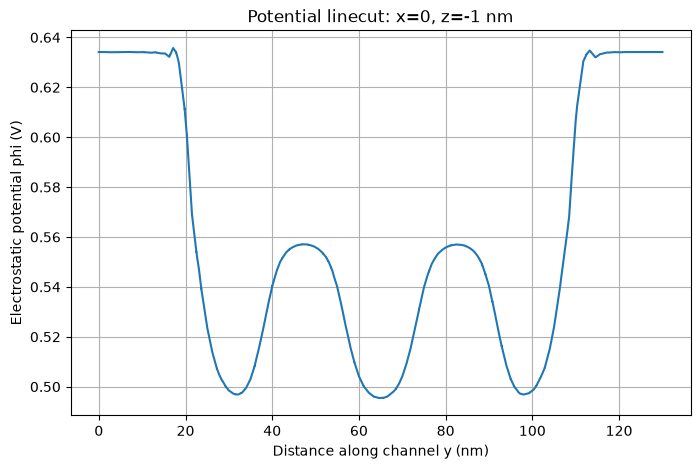

In [21]:
# [실험] y-direction electrostatic potential linecut
if HAVE_QTCAD:
    x_nodes, y_nodes, z_nodes = mesh_refined.glob_nodes.T
    ymin = np.min(y_nodes)
    ymax = np.max(y_nodes)

    distance_y, phi_line_y = an.linecut(
        mesh_refined,
        phi,
        (0.0, ymin, Z_PHI_LINECUT_NM * 1e-9),
        (0.0, ymax, Z_PHI_LINECUT_NM * 1e-9),
    )

    plt.figure(figsize=(8, 5))
    plt.plot(distance_y / 1e-9, phi_line_y)
    plt.xlabel("Distance along channel y (nm)")
    plt.ylabel("Electrostatic potential phi (V)")
    plt.title(f"Potential linecut: x=0, z={Z_PHI_LINECUT_NM:g} nm")
    plt.grid(True)

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "06_phi_linecut_y.png", dpi=180, bbox_inches="tight")

    plt.show()

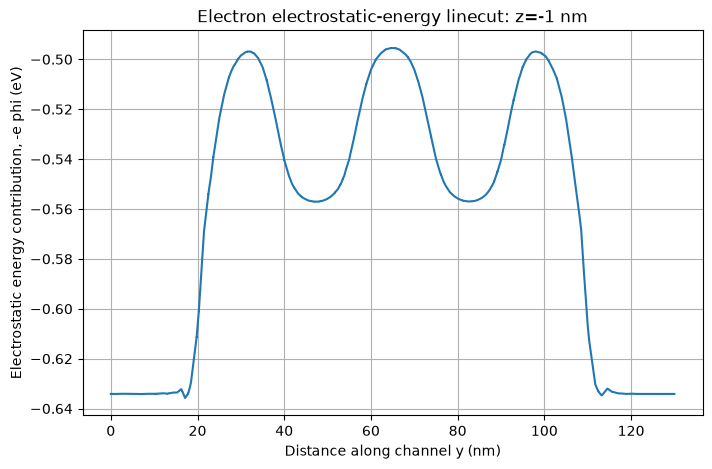

[주의] 이 값은 electrostatic contribution(-e phi)이며, material band offset까지 포함한 full conduction-band edge Ec와는 다릅니다.


In [22]:
# [실험] electron electrostatic-energy contribution (-e phi), eV 단위
# 1 electron charge에 대해 -e*phi [J] / e = -phi [eV]
if HAVE_QTCAD:
    electron_U_eV = -phi_line_y

    plt.figure(figsize=(8, 5))
    plt.plot(distance_y / 1e-9, electron_U_eV)
    plt.xlabel("Distance along channel y (nm)")
    plt.ylabel("Electrostatic energy contribution, -e phi (eV)")
    plt.title(f"Electron electrostatic-energy linecut: z={Z_PHI_LINECUT_NM:g} nm")
    plt.grid(True)

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "07_electron_electrostatic_energy_linecut.png", dpi=180, bbox_inches="tight")

    plt.show()

    print(
        "[주의] 이 값은 electrostatic contribution(-e phi)이며, "
        "material band offset까지 포함한 full conduction-band edge Ec와는 다릅니다."
    )

Target z       : -2.000 nm
Used |dz| tol  : 0.050 nm
Selected nodes : 818


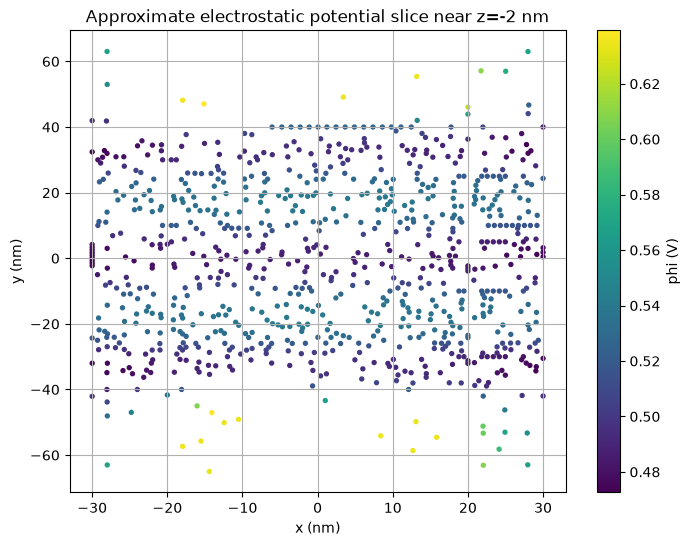

In [23]:
# [실험] refined mesh node를 이용한 z≈target plane 근사 2D potential map
if HAVE_QTCAD:
    x_nm = xyz_nm[:, 0]
    y_nm = xyz_nm[:, 1]
    z_nm = xyz_nm[:, 2]

    dz = np.abs(z_nm - Z_PHI_SLICE_NM)

    # 충분한 node가 포함될 때까지 slab 두께 자동 확대
    tolerance_candidates_nm = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
    mask = None
    used_tol = None

    for tol in tolerance_candidates_nm:
        candidate = dz <= tol
        if np.count_nonzero(candidate) >= 500:
            mask = candidate
            used_tol = tol
            break

    if mask is None:
        # fallback: target plane과 가까운 5000개 node
        idx = np.argsort(dz)[: min(5000, len(dz))]
        mask = np.zeros(len(dz), dtype=bool)
        mask[idx] = True
        used_tol = float(np.max(dz[idx]))

    print(f"Target z       : {Z_PHI_SLICE_NM:.3f} nm")
    print(f"Used |dz| tol  : {used_tol:.3f} nm")
    print(f"Selected nodes : {np.count_nonzero(mask):,}")

    # 너무 많은 점은 화면 표시용으로만 downsample
    idx_plot = np.flatnonzero(mask)
    if len(idx_plot) > 50000:
        step = int(np.ceil(len(idx_plot) / 50000))
        idx_plot = idx_plot[::step]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        x_nm[idx_plot],
        y_nm[idx_plot],
        c=phi[idx_plot],
        s=8,
    )
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.title(
        f"Approximate electrostatic potential slice near z={Z_PHI_SLICE_NM:g} nm"
    )
    plt.colorbar(scatter, label="phi (V)")
    plt.grid(True)

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "08_phi_slice_xy.png", dpi=180, bbox_inches="tight")

    plt.show()

In [24]:
# [동작] ParaView용 phi VTU export
if HAVE_QTCAD and EXPORT_POTENTIAL_VTU:
    potential_vtu = EXPORT_DIR / "tunnel_coupling_final_potential.vtu"
    io.save(str(potential_vtu), {"phi": phi}, mesh_refined)
    print("Saved:", potential_vtu)
    print("ParaView에서 Slice 후 Coloring=phi 로 보면 됩니다.")

Saved data in C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\analysis_exports\tunnel_coupling_final_potential.vtu
Estimated file size: 106.994 MB
Saved: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\analysis_exports\tunnel_coupling_final_potential.vtu
ParaView에서 Slice 후 Coloring=phi 로 보면 됩니다.


C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\qtcad\device\io.py:45: UserWarning: A large file (>10MB) was produced. Please make sure this is compatible with your memory capabilites.
  iop.save(


## 7. Wavefunction VTU 분석

VTU는 매우 큰 파일이므로 **high-barrier와 low-barrier를 한 번에 메모리에 유지하지 않고 하나씩 처리**합니다.

계산:
- VTU bounds / point 수 / cell 수 / field 이름
- \(\psi_0,\psi_1\) 최대 진폭 위치
- \(z=-2\) nm slice에서 \(|\psi|^2\) 정규화 지도
- channel 방향 \(y\) line profile
- raw wavefunction sign profile도 추출

> VTU 좌표는 이 예제 출력 기준 nm입니다.


In [25]:
# [동작] PyVista 준비
try:
    import pyvista as pv
    HAVE_PYVISTA = True
    print("[OK] PyVista import 성공:", pv.__version__)
except Exception as exc:
    HAVE_PYVISTA = False
    print("[주의] PyVista import 실패:", repr(exc))
    print("qtcad 환경에서 pyvista가 설치되어 있는지 확인하세요.")

[OK] PyVista import 성공: 0.49.0


In [26]:
# [동작] VTU 하나를 분석하는 함수
def analyze_wavefunction_vtu(vtu_path, condition_name, z_slice_nm=-2.0, line_resolution=600):
    if not HAVE_PYVISTA:
        return None

    print("=" * 80)
    print(condition_name)
    print(vtu_path)
    print("=" * 80)

    grid = pv.read(vtu_path)

    print("Points :", f"{grid.n_points:,}")
    print("Cells  :", f"{grid.n_cells:,}")
    print("Bounds :", grid.bounds)
    print("Point-data arrays:", list(grid.point_data.keys()))

    required = ["Ground state", "First excited state"]
    for name in required:
        if name not in grid.point_data:
            raise KeyError(f"{name!r}가 VTU에 없습니다.")

    metrics = []

    for state_name in required:
        psi = np.asarray(grid.point_data[state_name])
        prob = np.abs(psi) ** 2

        idx_max_abs = int(np.argmax(np.abs(psi)))
        xyz_peak = grid.points[idx_max_abs]

        metrics.append({
            "condition": condition_name,
            "state": state_name,
            "psi_min": float(np.min(psi)),
            "psi_max": float(np.max(psi)),
            "max_abs_psi": float(np.max(np.abs(psi))),
            "peak_x_nm": float(xyz_peak[0]),
            "peak_y_nm": float(xyz_peak[1]),
            "peak_z_nm": float(xyz_peak[2]),
        })

        # normalized probability field를 임시 추가
        max_prob = np.max(prob)
        grid.point_data[state_name + " probability norm"] = prob / max_prob

    # z slice
    sl = grid.slice(normal=(0, 0, 1), origin=(0, 0, z_slice_nm))

    slice_results = {}
    for state_name in required:
        field = state_name + " probability norm"
        slice_results[field] = {
            "points": np.asarray(sl.points).copy(),
            "values": np.asarray(sl.point_data[field]).copy(),
        }

    # y-direction line sample
    bounds = grid.bounds
    point_a = (0.0, bounds[2], z_slice_nm)
    point_b = (0.0, bounds[3], z_slice_nm)

    sampled = grid.sample_over_line(point_a, point_b, resolution=line_resolution)
    sample_points = np.asarray(sampled.points).copy()

    line_results = {
        "y_nm": sample_points[:, 1],
        "Ground state": np.asarray(sampled.point_data["Ground state"]).copy(),
        "First excited state": np.asarray(sampled.point_data["First excited state"]).copy(),
    }

    # 큰 grid 해제
    del sampled, sl, grid
    gc.collect()

    return {
        "metrics": metrics,
        "slice": slice_results,
        "line": line_results,
    }

In [27]:
# [동작] high-barrier VTU 분석
wf_high = None
if HAVE_PYVISTA and FILE_WF_HIGH.exists():
    wf_high = analyze_wavefunction_vtu(
        FILE_WF_HIGH,
        "High barrier (B2 ≈ 0.51 V)",
        z_slice_nm=Z_WF_SLICE_NM,
    )

High barrier (B2 ≈ 0.51 V)
C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\output\tunnel_coupling_wavefunctions_high_barrier.vtu


Points : 3,714,972
Cells  : 928,743
Bounds : BoundsTuple(x_min = -30.000000000000004,
            x_max =  30.000000000000004,
            y_min = -40.0,
            y_max =  40.0,
            z_min = -20.0,
            z_max =   2.0)
Point-data arrays: ['Ground state', 'First excited state']


In [28]:
# [동작] low-barrier VTU 분석
wf_low = None
if HAVE_PYVISTA and FILE_WF_LOW.exists():
    wf_low = analyze_wavefunction_vtu(
        FILE_WF_LOW,
        "Low barrier (B2 ≈ 0.57 V)",
        z_slice_nm=Z_WF_SLICE_NM,
    )

Low barrier (B2 ≈ 0.57 V)
C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\output\tunnel_coupling_wavefunctions_low_barrier.vtu


Points : 3,714,972
Cells  : 928,743
Bounds : BoundsTuple(x_min = -30.000000000000004,
            x_max =  30.000000000000004,
            y_min = -40.0,
            y_max =  40.0,
            z_min = -20.0,
            z_max =   2.0)
Point-data arrays: ['Ground state', 'First excited state']


In [29]:
# [동작] wavefunction peak 위치 표
wf_metrics = []

for result in [wf_high, wf_low]:
    if result is not None:
        wf_metrics.extend(result["metrics"])

if wf_metrics:
    wf_metrics_df = pd.DataFrame(wf_metrics)
    display(wf_metrics_df)

    wf_metrics_csv = EXPORT_DIR / "wavefunction_peak_metrics.csv"
    wf_metrics_df.to_csv(wf_metrics_csv, index=False)
    print("Saved:", wf_metrics_csv)

,condition,state,psi_min,psi_max,max_abs_psi,peak_x_nm,peak_y_nm,peak_z_nm
0,High barrier (B2 ≈ 0.51 V),Ground state,-4.511408e+10,1.105303e+12,1.105303e+12,-1.516226,-17.703514,-1.882409
1,High barrier (B2 ≈ 0.51 V),First excited state,-1.094042e+12,1.097011e+12,1.097011e+12,-1.516226,-17.703514,-1.882409
2,Low barrier (B2 ≈ 0.57 V),Ground state,-4.080147e+10,1.094270e+12,1.094270e+12,-1.362432,-15.532072,-1.997804
3,Low barrier (B2 ≈ 0.57 V),First excited state,-9.178192e+11,1.117823e+12,1.117823e+12,-2.059678,15.644342,-1.872545


Saved: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\analysis_exports\wavefunction_peak_metrics.csv


In [30]:
# [실험] wavefunction 2D probability slice plotting helper
def plot_probability_slice(result, state_name, file_name):
    if result is None:
        return

    key = state_name + " probability norm"
    pts = result["slice"][key]["points"]
    vals = result["slice"][key]["values"]

    # 표시량 제한
    if len(vals) > 100000:
        step = int(np.ceil(len(vals) / 100000))
        pts = pts[::step]
        vals = vals[::step]

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(pts[:, 0], pts[:, 1], c=vals, s=6)
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.ylabel("y (nm)")
    plt.title(f"{file_name.replace('_', ' ')} — {state_name} |psi|^2")
    plt.colorbar(sc, label="Normalized |psi|^2")
    plt.grid(True)

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / f"{file_name}.png", dpi=180, bbox_inches="tight")

    plt.show()

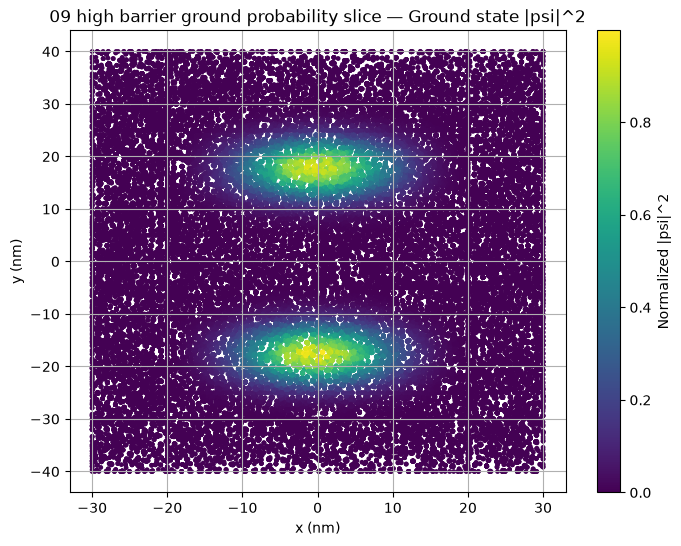

In [31]:
# [실험] High barrier |psi0|^2
plot_probability_slice(
    wf_high,
    "Ground state",
    "09_high_barrier_ground_probability_slice",
)

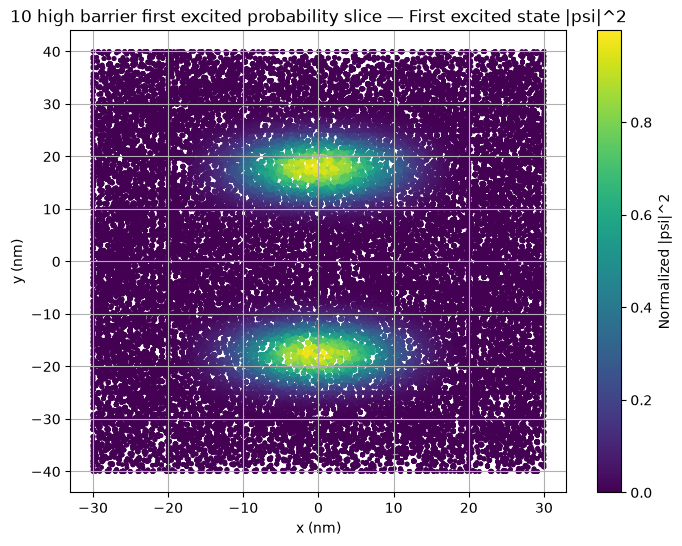

In [32]:
# [실험] High barrier |psi1|^2
plot_probability_slice(
    wf_high,
    "First excited state",
    "10_high_barrier_first_excited_probability_slice",
)

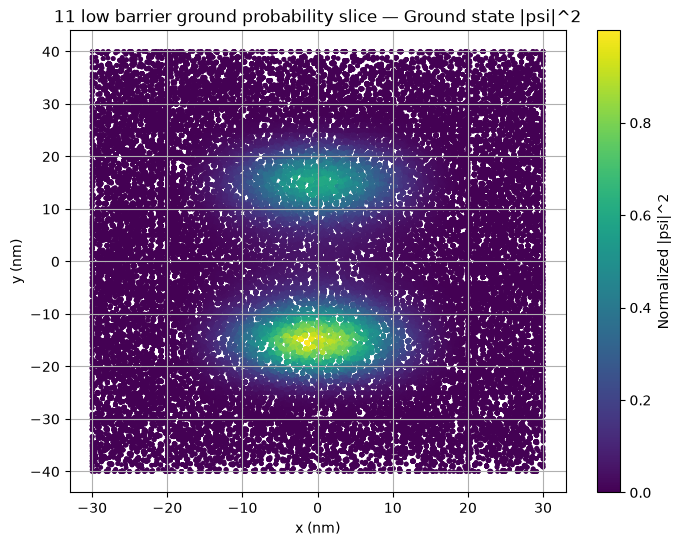

In [33]:
# [실험] Low barrier |psi0|^2
plot_probability_slice(
    wf_low,
    "Ground state",
    "11_low_barrier_ground_probability_slice",
)

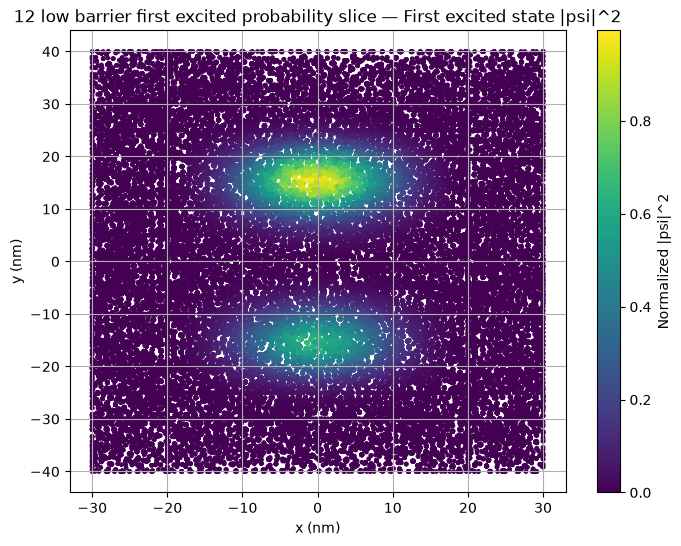

In [34]:
# [실험] Low barrier |psi1|^2
plot_probability_slice(
    wf_low,
    "First excited state",
    "12_low_barrier_first_excited_probability_slice",
)

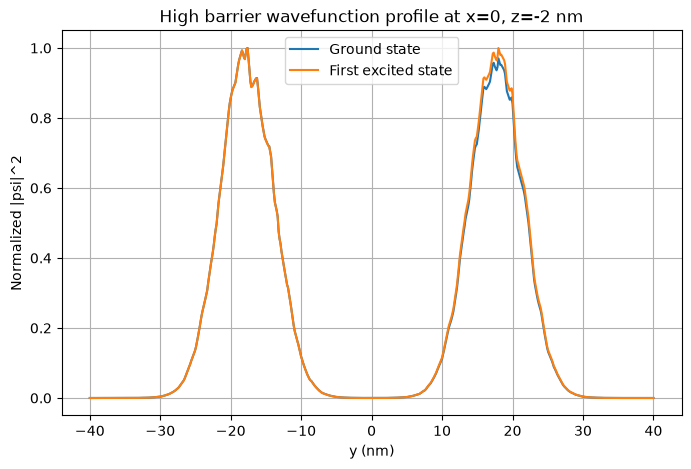

In [35]:
# [실험] channel-direction wavefunction probability profiles
def normalized_probability(psi):
    p = np.abs(psi) ** 2
    m = np.max(p)
    return p / m if m > 0 else p

if wf_high is not None:
    y = wf_high["line"]["y_nm"]
    p0 = normalized_probability(wf_high["line"]["Ground state"])
    p1 = normalized_probability(wf_high["line"]["First excited state"])

    plt.figure(figsize=(8, 5))
    plt.plot(y, p0, label="Ground state")
    plt.plot(y, p1, label="First excited state")
    plt.xlabel("y (nm)")
    plt.ylabel("Normalized |psi|^2")
    plt.title(f"High barrier wavefunction profile at x=0, z={Z_WF_SLICE_NM:g} nm")
    plt.grid(True)
    plt.legend()

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "13_high_barrier_wavefunction_line_profile.png",
                    dpi=180, bbox_inches="tight")
    plt.show()

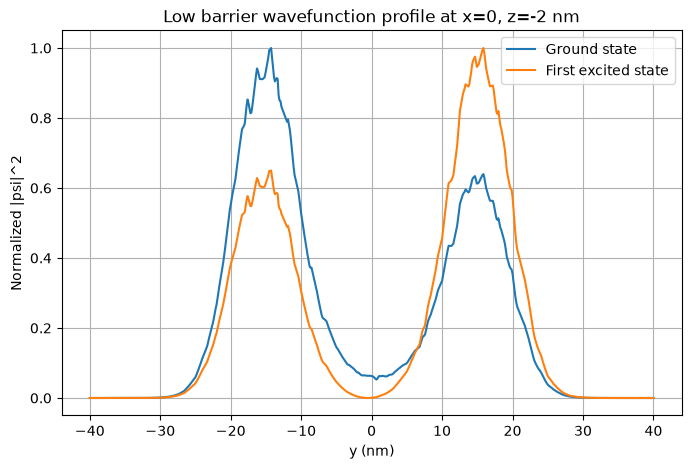

In [36]:
# [실험] Low barrier channel-direction probability profiles
if wf_low is not None:
    y = wf_low["line"]["y_nm"]
    p0 = normalized_probability(wf_low["line"]["Ground state"])
    p1 = normalized_probability(wf_low["line"]["First excited state"])

    plt.figure(figsize=(8, 5))
    plt.plot(y, p0, label="Ground state")
    plt.plot(y, p1, label="First excited state")
    plt.xlabel("y (nm)")
    plt.ylabel("Normalized |psi|^2")
    plt.title(f"Low barrier wavefunction profile at x=0, z={Z_WF_SLICE_NM:g} nm")
    plt.grid(True)
    plt.legend()

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "14_low_barrier_wavefunction_line_profile.png",
                    dpi=180, bbox_inches="tight")
    plt.show()

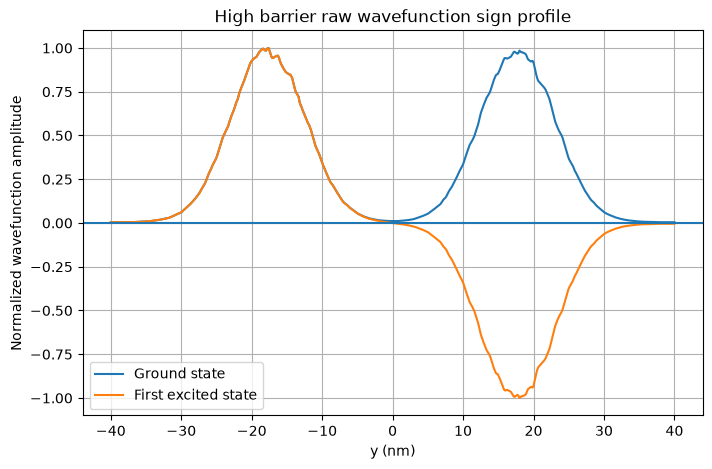

In [37]:
# [실험] Raw psi sign profile — high barrier
# first excited state의 부호 변화 / node를 보기 위한 그림
if wf_high is not None:
    y = wf_high["line"]["y_nm"]

    psi0 = wf_high["line"]["Ground state"]
    psi1 = wf_high["line"]["First excited state"]

    psi0_norm = psi0 / np.max(np.abs(psi0))
    psi1_norm = psi1 / np.max(np.abs(psi1))

    plt.figure(figsize=(8, 5))
    plt.plot(y, psi0_norm, label="Ground state")
    plt.plot(y, psi1_norm, label="First excited state")
    plt.axhline(0)
    plt.xlabel("y (nm)")
    plt.ylabel("Normalized wavefunction amplitude")
    plt.title("High barrier raw wavefunction sign profile")
    plt.grid(True)
    plt.legend()

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "15_high_barrier_raw_psi_line_profile.png",
                    dpi=180, bbox_inches="tight")
    plt.show()

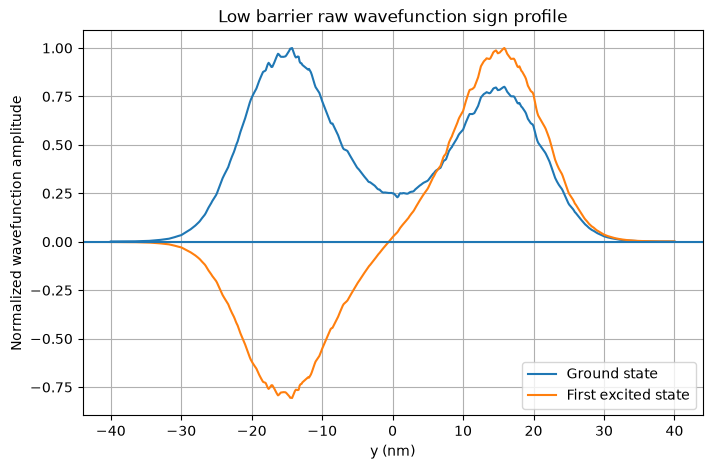

In [38]:
# [실험] Raw psi sign profile — low barrier
if wf_low is not None:
    y = wf_low["line"]["y_nm"]

    psi0 = wf_low["line"]["Ground state"]
    psi1 = wf_low["line"]["First excited state"]

    psi0_norm = psi0 / np.max(np.abs(psi0))
    psi1_norm = psi1 / np.max(np.abs(psi1))

    plt.figure(figsize=(8, 5))
    plt.plot(y, psi0_norm, label="Ground state")
    plt.plot(y, psi1_norm, label="First excited state")
    plt.axhline(0)
    plt.xlabel("y (nm)")
    plt.ylabel("Normalized wavefunction amplitude")
    plt.title("Low barrier raw wavefunction sign profile")
    plt.grid(True)
    plt.legend()

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "16_low_barrier_raw_psi_line_profile.png",
                    dpi=180, bbox_inches="tight")
    plt.show()

## 8. 최종 요약

In [39]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD M03 GATE SWEEP — FULL ANALYSIS SUMMARY")
print("=" * 88)

print(f"Optimal P2 detuning             : {detuning_uV:.6f} µV")
print(f"Optimal P2 voltage              : {P2_optimum_V:.9f} V")
print(f"Minimum tunnel splitting        : {np.min(splitting_ueV):.6f} µeV")
print(f"Maximum tunnel splitting        : {np.max(splitting_ueV):.6f} µeV")
print(f"Minimum splitting frequency     : {np.min(splitting_GHz):.6f} GHz")
print(f"Maximum splitting frequency     : {np.max(splitting_GHz):.6f} GHz")
print(f"Tuning ratio max/min            : {np.max(splitting_ueV)/np.min(splitting_ueV):.3f} x")
print(f"Exponential-fit alpha           : {alpha_per_V:.6f} 1/V")
print(f"Exponential-fit R^2 (log)       : {r2_log:.8f}")
print(f"HDF5 phi nodes                  : {len(phi):,}")
print(f"phi range                       : {np.min(phi):.9f} ~ {np.max(phi):.9f} V")

if HAVE_QTCAD:
    print(f"Original mesh nodes             : {n_original:,}")
    print(f"Refined mesh nodes              : {n_refined:,}")
    print(f"Mesh node refinement ratio      : {n_refined/n_original:.3f} x")

print(f"Analysis export directory       : {EXPORT_DIR}")
print("=" * 88)

QTCAD M03 GATE SWEEP — FULL ANALYSIS SUMMARY
Optimal P2 detuning             : -104.146286 µV
Optimal P2 voltage              : 0.589895854 V
Minimum tunnel splitting        : 1.301124 µeV
Maximum tunnel splitting        : 265.127865 µeV
Minimum splitting frequency     : 0.314610 GHz
Maximum splitting frequency     : 64.107632 GHz
Tuning ratio max/min            : 203.768 x
Exponential-fit alpha           : 81.414060 1/V
Exponential-fit R^2 (log)       : 0.98247170
HDF5 phi nodes                  : 173,626
phi range                       : 0.037004976 ~ 0.642936684 V
Original mesh nodes             : 1,057
Refined mesh nodes              : 173,626
Mesh node refinement ratio      : 164.263 x
Analysis export directory       : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M03. Gate sweep\Reference\analysis_exports


## 해석 주의사항

- `E1 - E0`는 이 예제에서 직접 계산되는 **tunnel splitting**입니다.
- 일반적인 2-level Hamiltonian에서 `ΔE = 2 t_c` convention을 쓰는 경우에는 `t_c = (E1-E0)/2`입니다. 논문/코드의 convention을 확인한 뒤 사용하십시오.
- HDF5의 `phi`는 **electrostatic potential**입니다. `-phi [eV]`는 전자의 electrostatic-energy contribution이지만, material band offset까지 포함한 full conduction-band edge \(E_C\)와 동일하지 않습니다.
- wavefunction VTU의 `Ground state`, `First excited state`는 amplitude입니다. 전자 위치를 직관적으로 볼 때는 \(|\psi|^2\)를 사용합니다.
- VTU line profile은 `x=0`, `z=Z_WF_SLICE_NM`에서 sampling한 결과입니다. 필요하면 상단 변수 `Z_WF_SLICE_NM`을 바꾸어 재실행하십시오.
